# Lab | Text Generation from Shakespeare's Sonnet

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku
import numpy as np

In [2]:
tokenizer = Tokenizer()
!wget --no-check-certificate \
    https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sonnets.txt \
    -O /tmp/sonnets.txt
data = """
from fairest creatures we desire increase
that thereby beauty's rose might never die
but as the riper should by time decease
his tender heir might bear his memory
but thou contracted to thine own bright eyes
feed'st thy light's flame with self-substantial fuel
making a famine where abundance lies
thyself thy foe to thy sweet self too cruel
thou that art now the world's fresh ornament
and only herald to the gaudy spring
within thine own bud buriest thy content
and tender churl mak'st waste in niggarding
pity the world or else this glutton be
to eat the world's due by the grave and thee

when forty winters shall besiege thy brow
and dig deep trenches in thy beauty's field
thy youth's proud livery so gazed on now
will be a tattered weed of small worth held
then being asked where all thy beauty lies
where all the treasure of thy lusty days
to say within thine own deep sunken eyes
were an all-eating shame and thriftless praise
how much more praise deserved thy beauty's use
if thou couldst answer this fair child of mine
shall sum my count and make my old excuse
proving his beauty by succession thine
this were to be new made when thou art old
and see thy blood warm when thou feel'st it cold
"""

corpus = data.lower().split("\n")


tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

# create input sequences using list of tokens
input_sequences = []
for line in corpus:
	token_list = tokenizer.texts_to_sequences([line])[0]
	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)


# pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# create predictors and label
predictors, label = input_sequences[:,:-1],input_sequences[:,-1]

label = ku.to_categorical(label, num_classes=total_words)

--2026-06-30 11:40:13--  https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sonnets.txt
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-30 11:40:13 ERROR 404: Not Found.



In [3]:
model = Sequential()
model.add(Embedding(
        total_words,
        100,
        input_length=max_sequence_len - 1
    ))
model.add(Bidirectional(
        LSTM(150, return_sequences=True)
    ))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(
        total_words // 2,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ))
model.add(Dense(
        total_words,
        activation='softmax'
    ))
optimizer = Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'])
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
history = model.fit(predictors, label, epochs=100, verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.0206 - loss: 5.5864
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0309 - loss: 5.1498
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0515 - loss: 5.0207
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0515 - loss: 4.9124
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0515 - loss: 4.7911
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0515 - loss: 4.7065
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0515 - loss: 4.6126
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0515 - loss: 4.5131
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0515 - loss: 4.4090
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0619 - loss: 4.3288
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0722 - loss: 4.2287
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0464 - lo

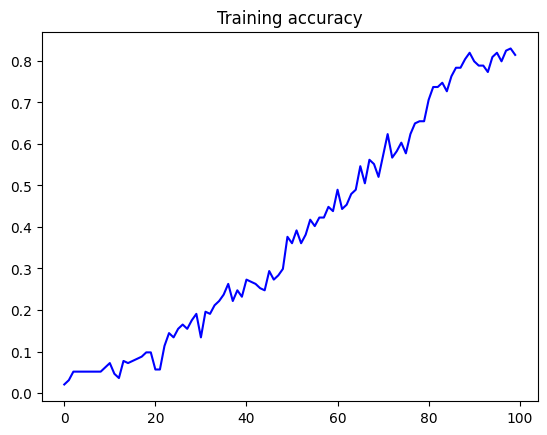

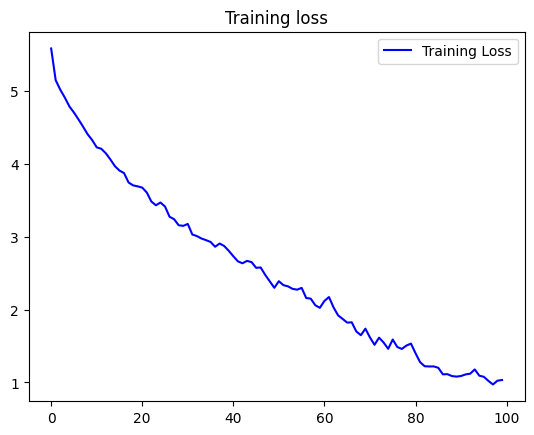

In [5]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training accuracy')

plt.figure()

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training loss')
plt.legend()

plt.show()

In [15]:
seed_text = "Help me Obi Wan Kenobi, you're my only hope"
next_words = 100

for _ in range(next_words):
	token_list = tokenizer.texts_to_sequences([seed_text])[0]
	token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
	predicted_probs = model.predict(token_list, verbose=0)
	predicted = np.argmax(predicted_probs, axis=-1)[0]
	output_word = ""
	for word, index in tokenizer.word_index.items():
		if index == predicted:
			output_word = word
			break
	seed_text += " " + output_word
print(seed_text)

Help me Obi Wan Kenobi, you're my only hope of thy sweet self too cruel cruel now thy sweet when sweet self too cruel cruel cruel feel'st grave and thee fresh now and grave and mak'st waste in niggarding his memory when thou feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my old excuse feel'st my
